# 单发多框检测（SSD）
:label:`sec_ssd`

在 :numref:`sec_bbox`— :numref:`sec_object-detection-dataset`中，我们分别介绍了边界框、锚框、多尺度目标检测和用于目标检测的数据集。
现在我们已经准备好使用这样的背景知识来设计一个目标检测模型：单发多框检测（SSD） :cite:`Liu.Anguelov.Erhan.ea.2016`。
该模型简单、快速且被广泛使用。尽管这只是其中一种目标检测模型，但本节中的一些设计原则和实现细节也适用于其他模型。

## 模型

 :numref:`fig_ssd`描述了单发多框检测模型的设计。
此模型主要由基础网络组成，其后是几个多尺度特征块。
基本网络用于从输入图像中提取特征，因此它可以使用深度卷积神经网络。
单发多框检测论文中选用了在分类层之前截断的VGG :cite:`Liu.Anguelov.Erhan.ea.2016`，现在也常用ResNet替代。
我们可以设计基础网络，使它输出的高和宽较大。
这样一来，基于该特征图生成的锚框数量较多，可以用来检测尺寸较小的目标。
接下来的每个多尺度特征块将上一层提供的特征图的高和宽缩小（如减半），并使特征图中每个单元在输入图像上的感受野变得更广阔。

回想一下在 :numref:`sec_multiscale-object-detection`中，通过深度神经网络分层表示图像的多尺度目标检测的设计。
由于接近 :numref:`fig_ssd`顶部的多尺度特征图较小，但具有较大的感受野，它们适合检测较少但较大的物体。
简而言之，通过多尺度特征块，单发多框检测生成不同大小的锚框，并通过预测边界框的类别和偏移量来检测大小不同的目标，因此这是一个多尺度目标检测模型。

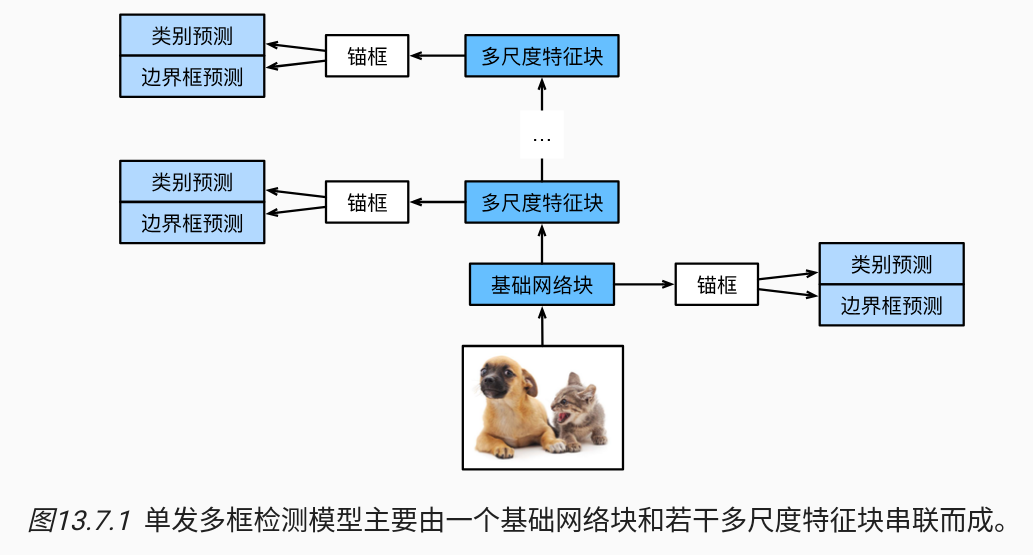

在下面，我们将介绍 :numref:`fig_ssd`中不同块的实施细节。
首先，我们将讨论如何实施类别和边界框预测。

### [**类别预测层**]

设目标类别的数量为$q$。这样一来，锚框有$q+1$个类别，其中0类是背景。
在某个尺度下，设特征图的高和宽分别为$h$和$w$。
如果以其中每个单元为中心生成$a$个锚框，那么我们需要对$hwa$个锚框进行分类。
如果使用全连接层作为输出，很容易导致模型参数过多。
回忆 :numref:`sec_nin`一节介绍的使用卷积层的通道来输出类别预测的方法，
单发多框检测采用同样的方法来降低模型复杂度。

具体来说，类别预测层使用一个保持输入高和宽的卷积层。
这样一来，输出和输入在特征图宽和高上的空间坐标一一对应。
考虑输出和输入同一空间坐标（$x$、$y$）：输出特征图上（$x$、$y$）坐标的通道里包含了以输入特征图（$x$、$y$）坐标为中心生成的所有锚框的类别预测。
因此输出通道数为$a(q+1)$，其中索引为$i(q+1) + j$（$0 \leq j \leq q$）的通道代表了索引为$i$的锚框有关类别索引为$j$的预测。

在下面，我们定义了这样一个类别预测层，通过参数`num_anchors`和`num_classes`分别指定了$a$和$q$。
该图层使用填充为1的$3\times3$的卷积层。此卷积层的输入和输出的宽度和高度保持不变。


In [1]:
%matplotlib inline
import torch
import torchvision
from torch import nn
from torch.nn import functional as F
from d2l import torch as d2l


def cls_predictor(num_inputs, num_anchors, num_classes):
    return nn.Conv2d(num_inputs, num_anchors * (num_classes + 1),
                     kernel_size=3, padding=1)

### (**边界框预测层**)

边界框预测层的设计与类别预测层的设计类似。
唯一不同的是，这里需要为每个锚框预测4个偏移量，而不是$q+1$个类别。


In [2]:
def bbox_predictor(num_inputs, num_anchors):
    return nn.Conv2d(num_inputs, num_anchors * 4, kernel_size=3, padding=1)

### [**连结多尺度的预测**]

正如我们所提到的，单发多框检测使用多尺度特征图来生成锚框并预测其类别和偏移量。
在不同的尺度下，特征图的形状或以同一单元为中心的锚框的数量可能会有所不同。
因此，不同尺度下预测输出的形状可能会有所不同。

在以下示例中，我们为同一个小批量构建两个不同比例（`Y1`和`Y2`）的特征图，其中`Y2`的高度和宽度是`Y1`的一半。
以类别预测为例，假设`Y1`和`Y2`的每个单元分别生成了$5$个和$3$个锚框。
进一步假设目标类别的数量为$10$，对于特征图`Y1`和`Y2`，类别预测输出中的通道数分别为$5\times(10+1)=55$和$3\times(10+1)=33$，其中任一输出的形状是（批量大小，通道数，高度，宽度）。


In [3]:
def forward(x, block):
    return block(x)

Y1 = forward(torch.zeros((2, 8, 20, 20)), cls_predictor(8, 5, 10))
Y2 = forward(torch.zeros((2, 16, 10, 10)), cls_predictor(16, 3, 10))
Y1.shape, Y2.shape

(torch.Size([2, 55, 20, 20]), torch.Size([2, 33, 10, 10]))

正如我们所看到的，除了批量大小这一维度外，其他三个维度都具有不同的尺寸。
为了将这两个预测输出链接起来以提高计算效率，我们将把这些张量转换为更一致的格式。

通道维包含中心相同的锚框的预测结果。我们首先将通道维移到最后一维。
因为不同尺度下批量大小仍保持不变，我们可以将预测结果转成二维的（批量大小，高$\times$宽$\times$通道数）的格式，以方便之后在维度$1$上的连结。


In [4]:
def flatten_pred(pred):
    return torch.flatten(pred.permute(0, 2, 3, 1), start_dim=1)

def concat_preds(preds):
    return torch.cat([flatten_pred(p) for p in preds], dim=1)

这样一来，尽管`Y1`和`Y2`在通道数、高度和宽度方面具有不同的大小，我们仍然可以在同一个小批量的两个不同尺度上连接这两个预测输出。


In [5]:
concat_preds([Y1, Y2]).shape

torch.Size([2, 25300])

### [**高和宽减半块**]

为了在多个尺度下检测目标，我们在下面定义了高和宽减半块`down_sample_blk`，该模块将输入特征图的高度和宽度减半。
事实上，该块应用了在 :numref:`subsec_vgg-blocks`中的VGG模块设计。
更具体地说，每个高和宽减半块由两个填充为$1$的$3\times3$的卷积层、以及步幅为$2$的$2\times2$最大汇聚层组成。
我们知道，填充为$1$的$3\times3$卷积层不改变特征图的形状。但是，其后的$2\times2$的最大汇聚层将输入特征图的高度和宽度减少了一半。
对于此高和宽减半块的输入和输出特征图，因为$1\times 2+(3-1)+(3-1)=6$，所以输出中的每个单元在输入上都有一个$6\times6$的感受野。因此，高和宽减半块会扩大每个单元在其输出特征图中的感受野。


In [6]:
import torch
import torch.nn as nn

def down_sample_blk(in_channels, out_channels):
    """构建一个下采样模块（Down-sampling Block）
    
    该模块通过堆叠卷积层提取特征并改变通道数，最后使用最大池化层将特征图的高和宽减半。
    通常用于单发多框检测（SSD）或 VGG 等网络架构中，用于多尺度特征提取。

    参数:
        in_channels:  输入特征图的通道数 (Channels)
        out_channels: 输出特征图的通道数 (Channels)

    返回:
        nn.Sequential: 打包好的神经网络模块容器
    """
    blk = []
    
    # 循环 2 次，构建两个连续的 [Conv -> BatchNorm -> ReLU] 基础结构
    for _ in range(2):
        # 1. 二维卷积层：采用 3x3 卷积核，填充 padding=1，步长 stride=1（默认）
        #    保持特征图的高和宽不变，仅改变/保持通道数
        blk.append(nn.Conv2d(in_channels, out_channels,
                             kernel_size=3, padding=1))
        # 感受野是3*3，经过两层之后是5*5
        # 2. 批归一化层 (Batch Normalization)：对输出通道进行归一化，加速收敛并稳定训练
        blk.append(nn.BatchNorm2d(out_channels))
        
        # 3. 激活函数层：引入非线性变换
        blk.append(nn.ReLU())
        
        # 4. 关键步：更新输入通道数！
        #    第一次循环后，通道数已变为 out_channels，因此第二次循环时输入的通道数也是 out_channels
        in_channels = out_channels
        
    # 5. 最大池化层 (Max Pooling)：采用 2x2 窗口，步长 stride=2（默认与 kernel_size 一致）
    #    作用：将特征图的高 (H) 和 宽 (W) 均减半，实现空间维度的下采样（Down-sampling）
    blk.append(nn.MaxPool2d(2))
    # 2*2池化，感受野变成6*6
    
    # 6. 使用解包运算符 * 将列表中的所有层解包，并打包为一个 Sequential 容器返回
    return nn.Sequential(*blk)

在以下示例中，我们构建的高和宽减半块会更改输入通道的数量，并将输入特征图的高度和宽度减半。


In [7]:
forward(torch.zeros((2, 3, 20, 20)), down_sample_blk(3, 10)).shape

torch.Size([2, 10, 10, 10])

### [**基本网络块**]

基本网络块用于从输入图像中抽取特征。
为了计算简洁，我们构造了一个小的基础网络，该网络串联3个高和宽减半块，并逐步将通道数翻倍。
给定输入图像的形状为$256\times256$，此基本网络块输出的特征图形状为$32 \times 32$（$256/2^3=32$）。


In [8]:
# 假设 down_sample_blk 已定义：包含 2 个 [Conv(k=3,p=1) -> BN -> ReLU] 和 1 个 MaxPool2d(2)
# 每个 down_sample_blk 会将特征图的高 HW 减半，并按传入的通道数改变 C

def base_net():
    """构建基础网络（Base Network）
    
    通常作为单发多框检测（SSD）的主干特征提取网络（Backbone）。
    该网络通过级联 3 个下采样模块（down_sample_blk），实现特征图分辨率的连续减半和通道数的逐步扩张。

    返回:
        nn.Sequential: 包含 3 个下采样模块的完整基础网络
    """
    blk = []
    # 定义各阶段的特征图通道数变化序列：
    # 3 (RGB输入通道) -> 16 (Block 1输出) -> 32 (Block 2输出) -> 64 (Block 3输出)
    num_filters = [3, 16, 32, 64]
    
    # 循环构建 3 个 down_sample_blk 模块：
    # i=0: down_sample_blk(3, 16)
    # i=1: down_sample_blk(16, 32)
    # i=2: down_sample_blk(32, 64)
    for i in range(len(num_filters) - 1):
        blk.append(down_sample_blk(num_filters[i], num_filters[i+1]))
        
    # 解包并打包为 Sequential 容器返回
    return nn.Sequential(*blk)

# ----------------------------------------------------------------------
# 测试前向传播并打印输出特征图的形状 (Shape)
# ----------------------------------------------------------------------
# 1. 构造一个形状为 [Batch_Size=2, Channels=3, Height=256, Width=256] 的全零虚构图像张量
input_tensor = torch.zeros((2, 3, 256, 256))

# 2. 实例化 base_net 网络
net = base_net()

# 3. 将输入传入网络执行前向传播 (forward)，并打印输出张量的形状
#    输出结果应为: torch.Size([2, 64, 32, 32])
print(forward(input_tensor, net).shape)

torch.Size([2, 64, 32, 32])


### 完整的模型

[**完整的单发多框检测模型由五个模块组成**]。每个块生成的特征图既用于生成锚框，又用于预测这些锚框的类别和偏移量。在这五个模块中，第一个是基本网络块，第二个到第四个是高和宽减半块，最后一个模块使用全局最大池将高度和宽度都降到1。从技术上讲，第二到第五个区块都是 :numref:`fig_ssd`中的多尺度特征块。


In [9]:
def get_blk(i):
    """根据索引 i 构建 SSD (单发多框检测) 特征金字塔中不同的特征提取块 (Block)
    
    SSD 通过网络的不同深度提取【多尺度特征图】来检测不同大小的目标：
    - 浅层特征图 (i 较小): 分辨率大，感受野小，适合检测【小目标】
    - 深层特征图 (i 较大): 分辨率小，感受野大，适合检测【大目标】

    参数:
        i (int): 特征块的层级索引 (0 <= i <= 4)

    返回:
        nn.Sequential / nn.Module: 对应索引层级的特征提取子网络块
    """
    if i == 0:
        # i = 0: 构建基础网络 (Base Network / Backbone)
        # 输入: [B, 3, 256, 256] -> 输出: [B, 64, 32, 32]
        # 作用: 抽取底层高分辨率特征，用于检测较小物体
        blk = base_net()
        
    elif i == 1:
        # i = 1: 第 1 个额外的下采样块，通道数从 64 增加到 128
        # 输入: [B, 64, 32, 32] -> 输出: [B, 128, 16, 16]
        # 作用: 特征图宽高减半，感受野增大，用于检测中等偏小的物体
        blk = down_sample_blk(64, 128)
        
    elif i == 4:
        # i = 4: 最后一个块，使用自适应最大池化层 (Adaptive Max Pooling)
        # 输入: [B, 128, 4, 4] -> 输出: [B, 128, 1, 1]
        # 作用: 无论输入尺寸多大，强制将特征图的空间分辨率压缩为 1x1，用于检测全图级别的最大目标
        blk = nn.AdaptiveMaxPool2d((1, 1))
        
    else:
        # i = 2 或 i = 3: 保持通道数为 128 的下采样块
        # i = 2 输入: [B, 128, 16, 16] -> 输出: [B, 128, 8, 8]
        # i = 3 输入: [B, 128, 8, 8]   -> 输出: [B, 128, 4, 4]
        # 作用: 持续下采样，递进式提取中等偏大和特大物体的抽象特征
        blk = down_sample_blk(128, 128)
        
    return blk

现在我们[**为每个块定义前向传播**]。与图像分类任务不同，此处的输出包括：CNN特征图`Y`；在当前尺度下根据`Y`生成的锚框；预测的这些锚框的类别和偏移量（基于`Y`）。


In [10]:
def blk_forward(X, blk, size, ratio, cls_predictor, bbox_predictor):
    """单个特征金字塔层级的多尺度检测前向传播函数
    
    该函数接收上一步的特征图，执行以下 4 个核心操作：
    1. 抽取当前层级的特征图 Y
    2. 在当前特征图上按指定大小和宽高比生成【锚框 (Anchors)】
    3. 预测当前层级每个锚框的【类别概率 (Class Predictions)】
    4. 预测当前层级每个锚框的【边界框偏移量 (Bounding Box Offsets)】

    参数:
        X:               输入特征图，形状为 [Batch_Size, In_Channels, H, W]
        blk:             当前层级的特征提取块 (例如 base_net 或 down_sample_blk)
        size:            当前层级锚框的缩放比列表 (Sizes, 如 [0.2, 0.272])
        ratio:           当前层级锚框的宽高比列表 (Ratios, 如 [1, 2, 0.5])
        cls_predictor:   类别预测网络 (通常是一个 3x3 卷积层)
        bbox_predictor:  边界框偏移量预测网络 (通常是一个 3x3 卷积层)

    返回:
        tuple: 包含 4 个元素的元组 (Y, anchors, cls_preds, bbox_preds)
    """
    # 1. 经过当前块提取更高阶/更小尺寸的特征图 Y
    #    维度变化: [B, C_in, H, W] -> [B, C_out, H', W'] (通常 H'=H/2, W'=W/2)
    Y = blk(X)
    
    # 2. 基于当前特征图 Y 的每一个像素网格生成锚框
    #    对于形状为 [H', W'] 的特征图，每个像素像素生成 a = len(size) + len(ratio) - 1 个锚框
    #    返回 anchors 形状: [1, H' * W' * a, 4] (归一化到 [0, 1] 相对坐标)
    anchors = d2l.multibox_prior(Y, sizes=size, ratios=ratio)
    
    # 3. 预测每个锚框属于各个类别的置信度得分
    #    返回 cls_preds 形状: [B, a * num_classes, H', W']
    cls_preds = cls_predictor(Y)
    
    # 4. 预测每个锚框相对于真实标注框 (Ground Truth) 的位置偏移量
    #    返回 bbox_preds 形状: [B, a * 4, H', W'] (每个锚框包含 4 个坐标偏移量 [Δx, Δy, Δw, Δh])
    bbox_preds = bbox_predictor(Y)
    
    # 5. 返回当前层级的全套预测信息（便于后续多层特征图拼接 concatenated）
    return (Y, anchors, cls_preds, bbox_preds)

回想一下，在 :numref:`fig_ssd`中，一个较接近顶部的多尺度特征块是用于检测较大目标的，因此需要生成更大的锚框。
在上面的前向传播中，在每个多尺度特征块上，我们通过调用的`multibox_prior`函数（见 :numref:`sec_anchor`）的`sizes`参数传递两个比例值的列表。
在下面，0.2和1.05之间的区间被均匀分成五个部分，以确定五个模块的在不同尺度下的较小值：0.2、0.37、0.54、0.71和0.88。
之后，他们较大的值由$\sqrt{0.2 \times 0.37} = 0.272$、$\sqrt{0.37 \times 0.54} = 0.447$等给出。

[~~超参数~~]


In [11]:
# ----------------------------------------------------------------------
# 1. 5 个特征金字塔层级的锚框缩放比 (Sizes)
# ----------------------------------------------------------------------
# sizes 包含了 5 个子列表，分别对应 SSD 网络 5 个不同特征层级 (get_blk(0) ~ get_blk(4))
# 每个子列表包含 2 个值 [s_i, sqrt(s_i * s_{i+1})]：
# - 第 1 个值: 当前层级的基准缩放比例 (相对于整张原图宽高的比例)
# - 第 2 个值: 当前层级与下一层级基准缩放比的【几何平均数】(用于过渡增强检测)
# 
# 可以看出: 随着层级加深 (0 -> 4)，size 从 0.2 增大到 0.88，代表【特征图越深，检测的目标尺寸越大】
sizes = [
    [0.2, 0.272],   # 层级 0 (特征图 32x32): 检测小目标 (约占原图 20%~27%)
    [0.37, 0.447],  # 层级 1 (特征图 16x16): 检测中偏小目标
    [0.54, 0.619],  # 层级 2 (特征图 8x8)  : 检测中等目标
    [0.71, 0.79],   # 层级 3 (特征图 4x4)  : 检测大目标
    [0.88, 0.961]   # 层级 4 (特征图 1x1)  : 检测特大/全局目标 (约占原图 88%~96%)
]

# ----------------------------------------------------------------------
# 2. 每个层级的锚框宽高比 (Ratios)
# ----------------------------------------------------------------------
# [[1, 2, 0.5]] * 5 利用 Python 列表乘法，将相同的宽高比配置重复 5 次，赋值给 5 个特征层
# - 1   : 正方形锚框 (宽高比 1:1)
# - 2   : 瘦长型锚框 (宽:高 = 2:1 -> 实际框形状为 宽>高)
# - 0.5 : 高瘦型锚框 (宽:高 = 1:2 -> 实际框形状为 高>宽)
ratios = [[1, 2, 0.5]] * 5

# ----------------------------------------------------------------------
# 3. 计算每个特征图像素点 (Pixel Grid) 生成的锚框总数 (num_anchors)
# ----------------------------------------------------------------------
# 在 SSD 的 multibox_prior 生成算法中，并不是对 sizes(n个) 和 ratios(m个) 做全组合 (n * m 个)，
# 而是采用一种【组合精简策略】以减少冗余计算，每个像素点只生成 n + m - 1 个锚框：
# - 包含 sizes[0] 与所有 ratios 的组合: (s1, r1), (s1, r2), (s1, r3) -> 共 m 个
# - 包含 ratios[0] 与剩余 sizes 的组合: (s2, r1)                  -> 共 n-1 个
#
# 计算过程: len(sizes[0]) = 2, len(ratios[0]) = 3
# num_anchors = 2 + 3 - 1 = 4
num_anchors = len(sizes[0]) + len(ratios[0]) - 1  # 结果为 4

现在，我们就可以按如下方式[**定义完整的模型**]`TinySSD`了。


In [12]:
class TinySSD(nn.Module):
    """TinySSD: 轻量级单发多框检测 (Single Shot MultiBox Detector) 模型
    
    网络包含 5 个特征金字塔层级，能够在不同分辨率的特征图上并行预测目标的【类别概率】与【边界框偏移量】。
    
    参数:
        num_classes (int): 预测的目标类别数量 (不包含背景类；实际预测时加上背景类为 num_classes + 1)
    """
    def __init__(self, num_classes, **kwargs):
        super(TinySSD, self).__init__(**kwargs)
        self.num_classes = num_classes
        
        # 记录 5 个特征金字塔层级 (Stage 0 ~ 4) 的输入通道数：
        # - Stage 0 (base_net): 输出 64 通道
        # - Stage 1 (down_sample_blk): 输出 128 通道
        # - Stage 2 ~ 4: 均输出 128 通道
        idx_to_in_channels = [64, 128, 128, 128, 128]
        
        # 循环构建并注册 5 个特征层级对应的【特征提取块】、【类别预测头】和【偏移量预测头】
        for i in range(5):
            # 1. 动态绑定特征提取块：self.blk_0 ~ self.blk_4
            #    等价于执行：self.blk_i = get_blk(i)
            setattr(self, f'blk_{i}', get_blk(i))
            
            # 2. 动态绑定类别预测卷积头：self.cls_0 ~ self.cls_4
            #    每个像素点的每个锚框输出 (num_classes + 1) 个类别的置信度得分
            setattr(self, f'cls_{i}', cls_predictor(idx_to_in_channels[i],
                                                    num_anchors, num_classes))
            
            # 3. 动态绑定边界框偏移量预测卷积头：self.bbox_0 ~ self.bbox_4
            #    每个像素点的每个锚框输出 4 个坐标偏移量 [Δx, Δy, Δw, Δh]
            setattr(self, f'bbox_{i}', bbox_predictor(idx_to_in_channels[i],
                                                      num_anchors))

    def forward(self, X):
        """前向传播过程
        
        参数:
            X: 输入图像张量，形状为 [Batch_Size, 3, Height, Width] (如 [2, 3, 256, 256])
            
        返回:
            tuple: (anchors, cls_preds, bbox_preds)
                - anchors:    全图拼接后的所有锚框坐标, 形状为 [1, total_anchors, 4]
                - cls_preds:  全图拼接后的类别预测得分, 形状为 [Batch_Size, total_anchors, num_classes + 1]
                - bbox_preds: 全图拼接后的偏移量预测值, 形状为 [Batch_Size, total_anchors * 4]
        """
        # 初始化长度为 5 的列表，用于暂存 5 个特征层级各自返回的结果
        anchors, cls_preds, bbox_preds = [None] * 5, [None] * 5, [None] * 5
        
        # 依次在 5 个特征金字塔层级上执行特征提取与预测
        for i in range(5):
            # getattr(self, f'blk_{i}') 动态获取实例变量 self.blk_i
            # 递进式传入 X：上一层的输出特征图 Y 会作为下一层的输入 X
            X, anchors[i], cls_preds[i], bbox_preds[i] = blk_forward(
                X, getattr(self, f'blk_{i}'), sizes[i], ratios[i],
                getattr(self, f'cls_{i}'), getattr(self, f'bbox_{i}'))
            
        # ------------------------------------------------------------------
        # 将 5 个层级的所有预测结果在【锚框/通道维度】上进行扁平化与拼接 (Concat)
        # ------------------------------------------------------------------
        
        # 1. 拼接所有锚框坐标：在 dim=1 维度上拼接
        #    各个 anchors[i] 形状均为 [1, N_i, 4]，拼接后形状变为 [1, 5444, 4]
        anchors = torch.cat(anchors, dim=1)
        
        # 2. 拼接所有层级的类别预测得分：concat_preds 会将特征图展平并拼接
        #    拼接后的形状为: [Batch_Size, 5444 * (num_classes + 1)]
        cls_preds = concat_preds(cls_preds)
        
        # 3. 整理类别预测得分的形状：将最后一维拆分为独立对应的类别数 (num_classes + 1)
        #    变形后的形状为: [Batch_Size, 5444, num_classes + 1]
        cls_preds = cls_preds.reshape(
            cls_preds.shape[0], -1, self.num_classes + 1)
        
        # 4. 拼接所有层级的边界框偏移量预测值
        #    拼接后的形状为: [Batch_Size, 5444 * 4]
        bbox_preds = concat_preds(bbox_preds)
        
        return anchors, cls_preds, bbox_preds

我们[**创建一个模型实例，然后使用它**]对一个$256 \times 256$像素的小批量图像`X`(**执行前向传播**)。

如本节前面部分所示，第一个模块输出特征图的形状为$32 \times 32$。
回想一下，第二到第四个模块为高和宽减半块，第五个模块为全局汇聚层。
由于以特征图的每个单元为中心有$4$个锚框生成，因此在所有五个尺度下，每个图像总共生成$(32^2 + 16^2 + 8^2 + 4^2 + 1)\times 4 = 5444$个锚框。


In [13]:
net = TinySSD(num_classes=1)
X = torch.zeros((32, 3, 256, 256))
anchors, cls_preds, bbox_preds = net(X)

print('output anchors:', anchors.shape)
print('output class preds:', cls_preds.shape)
print('output bbox preds:', bbox_preds.shape)

/home/zhangjinrui/anaconda3/envs/pytorch/lib/python3.10/site-packages/torch/functional.py:534: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /opt/conda/conda-bld/pytorch_1729647352509/work/aten/src/ATen/native/TensorShape.cpp:3595.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


output anchors: torch.Size([1, 5444, 4])
output class preds: torch.Size([32, 5444, 2])
output bbox preds: torch.Size([32, 21776])


## 训练模型

现在，我们将描述如何训练用于目标检测的单发多框检测模型。

### 读取数据集和初始化

首先，让我们[**读取**] :numref:`sec_object-detection-dataset`中描述的(**香蕉检测数据集**)。


In [14]:
batch_size = 32
train_iter, _ = d2l.load_data_bananas(batch_size)

read 1000 training examples
read 100 validation examples


香蕉检测数据集中，目标的类别数为1。
定义好模型后，我们需要(**初始化其参数并定义优化算法**)。


In [15]:
device, net = d2l.try_gpu(), TinySSD(num_classes=1)
trainer = torch.optim.SGD(net.parameters(), lr=0.2, weight_decay=5e-4)

### [**定义损失函数和评价函数**]

目标检测有两种类型的损失。
第一种有关锚框类别的损失：我们可以简单地复用之前图像分类问题里一直使用的交叉熵损失函数来计算；
第二种有关正类锚框偏移量的损失：预测偏移量是一个回归问题。
但是，对于这个回归问题，我们在这里不使用 :numref:`subsec_normal_distribution_and_squared_loss`中描述的平方损失，而是使用$L_1$范数损失，即预测值和真实值之差的绝对值。
掩码变量`bbox_masks`令负类锚框和填充锚框不参与损失的计算。
最后，我们将锚框类别和偏移量的损失相加，以获得模型的最终损失函数。


In [16]:
import torch
import torch.nn as nn

# 1. 初始化分类损失和回归损失函数
# 设置 reduction='none' 关键点：不自动对整个 Batch 或所有锚框求平均/求和，
# 而是保留每个样本、每个锚框独立的 Loss 标量，方便后续根据掩码 (Mask) 灵活过滤和计算平均。
cls_loss = nn.CrossEntropyLoss(reduction='none')
bbox_loss = nn.L1Loss(reduction='none')

def calc_loss(cls_preds, cls_labels, bbox_preds, bbox_labels, bbox_masks):
    """计算 SSD 模型的联合总损失 (Total Loss = 分类损失 + 边界框回归损失)
    
    参数:
        cls_preds:   类别预测得分, 形状为 [Batch_Size, num_anchors, num_classes + 1]
        cls_labels:  类别真实标签, 形状为 [Batch_Size, num_anchors] (背景类通常为 0)
        bbox_preds:  偏移量预测值, 形状为 [Batch_Size, num_anchors * 4]
        bbox_labels: 偏移量真实标签, 形状为 [Batch_Size, num_anchors * 4]
        bbox_masks:  边界框掩码矩阵, 形状为 [Batch_Size, num_anchors * 4]
                     (正样本锚框对应位置为 1，背景/负样本锚框对应位置为 0)
                     
    返回:
        torch.Tensor: 每个样本的联合总损失，形状为 [Batch_Size]
    """
    # 获取 Batch 大小以及包括背景类在内的总类别数
    batch_size, num_classes = cls_preds.shape[0], cls_preds.shape[2]
    
    # ------------------------------------------------------------------
    # 2. 计算分类损失 (Classification Loss)
    # ------------------------------------------------------------------
    # - cls_preds.reshape(-1, num_classes): 将 [B, N, C] 展平为二维矩阵 [(B * N), C] 以适应 CrossEntropyLoss 的输入要求
    # - cls_labels.reshape(-1):            将 [B, N] 展平为一维向量 [(B * N)]
    # - 经过 cls_loss 后得到形状为 [(B * N)] 的扁平化损失向量
    # - .reshape(batch_size, -1):          重新还原为 [Batch_Size, num_anchors] 形状
    # - .mean(dim=1):                      在锚框维度 (dim=1) 上求平均，得到当前图像中所有锚框的平均分类损失
    # 最终 cls 形状为: [Batch_Size]
    cls = cls_loss(cls_preds.reshape(-1, num_classes),
                   cls_labels.reshape(-1)).reshape(batch_size, -1).mean(dim=1)
    
    # ------------------------------------------------------------------
    # 3. 计算边界框回归损失 (Bounding Box Offset Loss)
    # ------------------------------------------------------------------
    # 核心细节：乘以 bbox_masks！
    # - 对于背景/负样本锚框，bbox_masks 对应的 4 个位置全为 0
    # - 0 乘任何预测和标签后都变为 0，从而【屏蔽/过滤掉负样本框对回归损失的干扰】
    #   （因为背景框没有真实边界框，不需要预测偏移量）
    # - bbox_loss 计算出的损失矩阵形状为 [Batch_Size, num_anchors * 4]
    # - .mean(dim=1): 在维度 1 上求平均，得到每张图片的平均边界框损失
    # 最终 bbox 形状为: [Batch_Size]
    bbox = bbox_loss(bbox_preds * bbox_masks,
                     bbox_labels * bbox_masks).mean(dim=1)
    
    # ------------------------------------------------------------------
    # 4. 联合损失 (Total Loss)
    # ------------------------------------------------------------------
    # 将分类损失和回归损失直接相加（在此简单加权，权重均为 1）
    # 返回形状为 [Batch_Size] 的张量，表示 Batch 中每张图片的损失值
    return cls + bbox

我们可以沿用准确率评价分类结果。
由于偏移量使用了$L_1$范数损失，我们使用*平均绝对误差*来评价边界框的预测结果。这些预测结果是从生成的锚框及其预测偏移量中获得的。


In [17]:
import torch

def cls_eval(cls_preds, cls_labels):
    """计算分类正确的锚框总数量 (Classification Accuracy Count)
    
    参数:
        cls_preds  (Tensor): 类别预测得分，形状为 [Batch_Size, num_anchors, num_classes + 1]
                             最后一维存放的是各类别的置信度得分 (含背景类)
        cls_labels (Tensor): 真实类别标签，形状为 [Batch_Size, num_anchors]
                             元素值为类别索引 (如 0 表示背景，1, 2... 表示目标类)
                             
    返回:
        float: 当前 Batch 内所有预测正确的锚框总数
    """
    # 1. cls_preds.argmax(dim=-1):
    #    沿着最后一维 (dim=-1) 取最大概率的索引值，得到预测类别。
    #    变换前形状: [Batch_Size, num_anchors, num_classes + 1]
    #    变换后形状: [Batch_Size, num_anchors]
    #
    # 2. .type(cls_labels.dtype):
    #    将预测得到的索引张量数据类型转换为与 cls_labels 一致 (通常为 torch.int64 或 torch.int32)，
    #    确保后续的比较操作 `==` 能够安全执行（避免类型不匹配报错）。
    #
    # 3. == cls_labels:
    #    逐元素比较预测类别与真实标签，相同为 True (1)，不同为 False (0)。
    #    生成形状为 [Batch_Size, num_anchors] 的布尔型张量 (BoolTensor)。
    #
    # 4. .sum():
    #    对整张张量求和，统计所有预测正确的锚框数量 (True 的个数)。
    #
    # 5. float(...):
    #    将 PyTorch 的 0 维标量张量转换为 Python 的原生浮点数，方便后续进行累加计算。
    return float((cls_preds.argmax(dim=-1).type(
        cls_labels.dtype) == cls_labels).sum())


def bbox_eval(bbox_preds, bbox_labels, bbox_masks):
    """计算所有正样本锚框的边界框偏移量绝对误差总和 (Absolute Bounding Box Error Sum)
    
    参数:
        bbox_preds  (Tensor): 预测的边界框偏移量，形状为 [Batch_Size, num_anchors * 4]
        bbox_labels (Tensor): 真实的边界框偏移量，形状为 [Batch_Size, num_anchors * 4]
        bbox_masks  (Tensor): 边界框掩码矩阵，形状为 [Batch_Size, num_anchors * 4]
                              (正样本/目标框对应位置为 1，负样本/背景框对应位置为 0)
                              
    返回:
        float: 当前 Batch 内所有【正样本锚框】坐标预测值与真实值之间的 L1 绝对误差之和
    """
    # 1. (bbox_labels - bbox_preds):
    #    计算预测偏移量与真实偏移量之间的残差/差值。
    #
    # 2. * bbox_masks:
    #    核心掩码过滤！
    #    将残差矩阵与掩码矩阵进行逐元素相乘。由于负样本 (背景) 的 bbox_masks 全为 0，
    #    乘法会将背景锚框的残差【精准置零】，从而屏蔽背景框对坐标预测评估的干扰。
    #
    # 3. torch.abs(...):
    #    对过滤后的残差矩阵求绝对值 (即 L1 距离)。
    #
    # 4. .sum():
    #    对张量内的所有元素求和，得到整体的绝对误差和。
    #
    # 5. float(...):
    #    转换为 Python 原生浮点数，便于累加。
    return float((torch.abs((bbox_labels - bbox_preds) * bbox_masks)).sum())

### [**训练模型**]

在训练模型时，我们需要在模型的前向传播过程中生成多尺度锚框（`anchors`），并预测其类别（`cls_preds`）和偏移量（`bbox_preds`）。
然后，我们根据标签信息`Y`为生成的锚框标记类别（`cls_labels`）和偏移量（`bbox_labels`）。
最后，我们根据类别和偏移量的预测和标注值计算损失函数。为了代码简洁，这里没有评价测试数据集。


RuntimeError: CUDA unknown error - this may be due to an incorrectly set up environment, e.g. changing env variable CUDA_VISIBLE_DEVICES after program start. Setting the available devices to be zero.

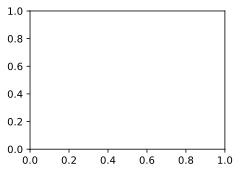

In [18]:
# 1. 训练参数与计时器/动画组件初始化
num_epochs, timer = 20, d2l.Timer()  # 训练 20 个迭代周期，初始化 PyTorch/D2L 计时器
animator = d2l.Animator(xlabel='epoch', xlim=[1, num_epochs],
                        legend=['class error', 'bbox mae'])  # 实时绘制分类错误率和回归 MAE 的动画图表

# 2. 将 TinySSD 模型加载到指定的计算设备（CPU 或 GPU/CUDA）
net = net.to(device)

# 3. 开始 Epoch 训练循环
for epoch in range(num_epochs):
    # 初始化累加器 Metric，用于累加当前 Epoch 的 4 个统计数值：
    # metric[0]: 分类预测正确的锚框总数 (cls_eval)
    # metric[1]: 参与分类预测的锚框总元素数 (cls_labels.numel())
    # metric[2]: 正样本锚框边界框偏移量的绝对误差和 (bbox_eval)
    # metric[3]: 参与回归计算的偏移量元素总数 (bbox_labels.numel())
    metric = d2l.Accumulator(4)
    
    # 开启模型的训练模式（使能 Dropout / BatchNorm 的训练状态）
    net.train()
    
    # 遍历训练数据加载器 (train_iter) 中的每个 Batch
    for features, target in train_iter:
        timer.start()           # 启动计时器，记录本 Batch 的处理时间
        trainer.zero_grad()     # 梯度清零，防止上一次 Batch 的梯度累加
        
        # 将输入图像 features 和真实目标框标注 target 搬运到 GPU/CPU
        X, Y = features.to(device), target.to(device)
        
        # ------------------------------------------------------------------
        # 核心前向传播与目标匹配
        # ------------------------------------------------------------------
        # 1. 前向传播：网络提取 5 个特征金字塔层级，生成全图锚框并预测类别和偏移量
        #    anchors: [1, 5444, 4], cls_preds: [B, 5444, C+1], bbox_preds: [B, 5444*4]
        anchors, cls_preds, bbox_preds = net(X)
        
        # 2. 目标分配（Target Assignment/IoU 匹配）：
        #    根据真实标签 Y 和生成的 anchors，利用匈牙利算法/最大 IoU 原则：
        #    - 为每一个锚框分配真实的类别标签 cls_labels [B, 5444]
        #    - 计算每个锚框相对于真实框的偏移量 bbox_labels [B, 5444*4]
        #    - 生成掩码 bbox_masks [B, 5444*4] (正样本为 1，负样本/背景为 0)
        bbox_labels, bbox_masks, cls_labels = d2l.multibox_target(anchors, Y)
        
        # ------------------------------------------------------------------
        # 损失计算与反向传播
        # ------------------------------------------------------------------
        # 3. 计算结合了分类和坐标回归的总损失 (返回形状为 [Batch_Size] 的损失张量)
        l = calc_loss(cls_preds, cls_labels, bbox_preds, bbox_labels, bbox_masks)
        
        # 4. 对 Batch 内所有样本的 Loss 求均值后，执行反向传播计算梯度
        l.mean().backward()
        
        # 5. 优化器更新网络参数
        trainer.step()
        
        # ------------------------------------------------------------------
        # 指标统计与累加
        # ------------------------------------------------------------------
        # 将当前 Batch 的评估指标累加进 metric 容器中
        metric.add(cls_eval(cls_preds, cls_labels), cls_labels.numel(),
                   bbox_eval(bbox_preds, bbox_labels, bbox_masks),
                   bbox_labels.numel())
        
    # ----------------------------------------------------------------------
    # 计算当前 Epoch 的平均评估指标并在动画曲线上绘制
    # ----------------------------------------------------------------------
    # 分类错误率 (Class Error) = 1 - (正确分类的锚框数 / 锚框总数)
    # 边界框平均绝对误差 (Bbox MAE) = 绝对误差和 / 偏移量元素总数
    cls_err, bbox_mae = 1 - metric[0] / metric[1], metric[2] / metric[3]
    
    # 将当前 Epoch 的结果添加到动画折线图上进行实时展示
    animator.add(epoch + 1, (cls_err, bbox_mae))

# 4. 训练结束，打印最终的训练评估结果
print(f'class err {cls_err:.2e}, bbox mae {bbox_mae:.2e}')

# 5. 停止计时并计算打印训练吞吐量 (吞吐率 = 总处理图像数 / 耗费的总秒数)
print(f'{len(train_iter.dataset) / timer.stop():.1f} examples/sec on '
      f'{str(device)}')

## [**预测目标**]

在预测阶段，我们希望能把图像里面所有我们感兴趣的目标检测出来。在下面，我们读取并调整测试图像的大小，然后将其转成卷积层需要的四维格式。


In [ ]:
X = torchvision.io.read_image('../img/banana.jpg').unsqueeze(0).float()
img = X.squeeze(0).permute(1, 2, 0).long()

使用下面的`multibox_detection`函数，我们可以根据锚框及其预测偏移量得到预测边界框。然后，通过非极大值抑制来移除相似的预测边界框。


In [ ]:

def predict(X):
    """SSD 单发多框检测模型的预测/推理函数 (Inference)
    
    参数:
        X (Tensor): 单张或多张测试图像张量，形状为 [Batch_Size, 3, Height, Width]
                    (注意：这里传入的 X 通常未加 Batch 维，需用 X.unsqueeze(0) 或单张图像 Batch)
                    
    返回:
        Tensor: 经过 NMS (非极大值抑制) 过滤掉背景框后的最终有效预测框矩阵，
                形状为 [N_valid, 6]，每一行包含 6 个元素：
                [predicted_class_id, confidence_score, x_min, y_min, x_max, y_max]
    """
    # 1. 开启模型的评估模式 (Evaluation Mode)
    #    关闭 Dropout 和 BatchNorm 的动态更新，确保推理结果稳定一致
    net.eval()
    
    # 2. 将输入张量搬运至计算设备 (CPU 或 GPU/CUDA) 并进行前向传播
    #    - anchors:    全图锚框坐标，形状为 [1, 5444, 4]
    #    - cls_preds:  类别预测得分，形状为 [Batch_Size, 5444, num_classes + 1]
    #    - bbox_preds: 偏移量预测值，形状为 [Batch_Size, 5444 * 4]
    anchors, cls_preds, bbox_preds = net(X.to(device))
    
    # 3. 计算 Softmax 概率矩阵并转置维度以适配 multibox_detection 的输入格式
    #    - F.softmax(cls_preds, dim=2): 对最后一维 (类别维) 求概率分布，使得各类概率和为 1
    #      形状保持为: [Batch_Size, 5444, num_classes + 1]
    #    - .permute(0, 2, 1): 交换维度 1 和维度 2！
    #      变换后的形状为: [Batch_Size, num_classes + 1, 5444]
    #      (因为 multibox_detection 要求第 1 维是类别通道，第 2 维是锚框通道)
    cls_probs = F.softmax(cls_preds, dim=2).permute(0, 2, 1)
    
    # 4. 执行非极大值抑制 (Non-Maximum Suppression, NMS) 过滤重叠框
    #    - 根据偏移量 bbox_preds 调整原始锚框 anchors 得到预测边界框
    #    - 根据阈值过滤概率较低的预测框，并对同一类别的重叠框按 IoU 实施抑制
    #    - 返回形状为 [Batch_Size, 5444, 6] 的预测矩阵
    output = d2l.multibox_detection(cls_probs, bbox_preds, anchors)
    
    # 5. 过滤掉被标记为背景/无效框 (row[0] == -1) 的候选框
    #    output[0] 表示取 Batch 中第 0 张图片的预测结果，形状为 [5444, 6]
    #    row[0] 是预测类别 ID，如果被 NMS 置为 -1 代表该框为背景或已被抑制抛弃
    idx = [i for i, row in enumerate(output[0]) if row[0] != -1]
    
    # 6. 仅提取有效检测目标（类别 ID != -1）的预测行并返回
    #    返回形状为 [N_valid, 6] 的二维矩阵
    return output[0, idx]

# ----------------------------------------------------------------------
# 测试预测函数
# ----------------------------------------------------------------------
# 假设 X 是处理好的输入图像张量 (加了 Batch 维，如 [1, 3, 256, 256])
output = predict(X)

最后，我们[**筛选所有置信度不低于0.9的边界框，做为最终输出**]。


In [ ]:
def display(img, output, threshold):
    """在输入图像上绘制高于置信度阈值的最终预测边界框 (Bounding Boxes)
    
    参数:
        img (Tensor/ndarray): 待展示的原始图像对象，形状为 [H, W, C]
        output (Tensor):      经过 predict() 和 NMS 过滤后的有效预测框矩阵，
                              形状为 [N_valid, 6]，每行为 [class_id, score, xmin, ymin, xmax, ymax]
        threshold (float):    置信度得分阈值 (0 ~ 1)，只有 score >= threshold 的框才会绘制展示
    """
    # 1. 设置 Matplotlib 绘图画布的大小为 5x5 英寸
    d2l.set_figsize((5, 5))
    
    # 2. 渲染原始图像，并获取对应的图像轴对象 (Axes)
    fig = d2l.plt.imshow(img)
    
    # 3. 遍历每一个有效预测框 (每一行代表一个候选框)
    for row in output:
        # 提取当前预测框的置信度得分 (score) 并转为 Python 原生 float
        score = float(row[1])
        
        # 4. 置信度阈值过滤：如果得分低于设定的 threshold，直接跳过不画
        if score < threshold:
            continue
            
        # 5. 获取图像的实际像素高度 H 和宽度 W
        h, w = img.shape[0:2]
        
        # ------------------------------------------------------------------
        # 6. 反向缩放坐标 (Denormalization / Anti-normalization)
        # ------------------------------------------------------------------
        # - row[2:6] 存储的是 [xmin, ymin, xmax, ymax] 的【相对归一化坐标】(取值范围 0 ~ 1)
        # - torch.tensor((w, h, w, h)): 构造匹配宽高的缩放因子向量
        # - row.device: 动态获取当前张量所在的计算设备 (CPU/GPU)，防止设备不一致报错
        # - 相乘后得到在原始图像尺寸下的【实际像素坐标】: [xmin*w, ymin*h, xmax*w, ymax*h]
        bbox = [row[2:6] * torch.tensor((w, h, w, h), device=row.device)]
        
        # 7. 调用 D2L 绘图工具在图像轴 (fig.axes) 上绘制边界框
        #    - '%.2f' % score: 将置信度保留 2 位小数作为标签显示 (如 "0.85")
        #    - 'w': 标签文本颜色设置为白色 (white)
        d2l.show_bboxes(fig.axes, bbox, '%.2f' % score, 'w')

# ----------------------------------------------------------------------
# 函数调用与测试
# ----------------------------------------------------------------------
# 避坑细节：使用 output.cpu() 将张量从 GPU 复制到 CPU 内存中！
# 因为 Matplotlib 和图像显示库无法直接操作 GPU 显存上的 PyTorch 张量。
display(img, output.cpu(), threshold=0.6)

## 小结

* 单发多框检测是一种多尺度目标检测模型。基于基础网络块和各个多尺度特征块，单发多框检测生成不同数量和不同大小的锚框，并通过预测这些锚框的类别和偏移量检测不同大小的目标。
* 在训练单发多框检测模型时，损失函数是根据锚框的类别和偏移量的预测及标注值计算得出的。

## 练习

1. 能通过改进损失函数来改进单发多框检测吗？例如，将预测偏移量用到的$L_1$范数损失替换为平滑$L_1$范数损失。它在零点附近使用平方函数从而更加平滑，这是通过一个超参数$\sigma$来控制平滑区域的：

$$
f(x) =
    \begin{cases}
    (\sigma x)^2/2,& \text{if }|x| < 1/\sigma^2\\
    |x|-0.5/\sigma^2,& \text{otherwise}
    \end{cases}
$$

当$\sigma$非常大时，这种损失类似于$L_1$范数损失。当它的值较小时，损失函数较平滑。


In [ ]:
def smooth_l1(data, scalar):
    """计算带缩放因子 (scalar/sigma) 的 Smooth L1 损失函数 (平滑 L1 损失)
    
    Smooth L1 Loss 结合了 L1 Loss 和 L2 Loss 的优点：
    - 在误差较小时 (|x| 较小)：表现为二次函数 (L2 Loss)，梯度平滑，利于收敛且不会振荡；
    - 在误差较大时 (|x| 较大)：表现为一次函数 (L1 Loss)，梯度恒定，对异常值 (Outliers) 不敏感，鲁棒性强。

    参数:
        data (iterable):   输入预测误差向量 x (即 bbox_preds - bbox_labels)
        scalar (float):    超参数 σ (sigma)，控制平滑区域的转折门槛与二次函数的陡峭程度

    返回:
        torch.Tensor: 对应每个输入误差的 Smooth L1 损失值张量
    """
    out = []
    # 逐元素遍历输入数据点
    for i in data:
        # 1. 阈值判断：|x| < 1 / (σ^2)
        #    当误差绝对值小于临界门槛时，进入【小误差 L2 平滑区域】
        if abs(i) < 1 / (scalar ** 2):
            # 公式: (σ * x)^2 / 2
            out.append(((scalar * i) ** 2) / 2)
        # 2. 否则进入【大误差 L1 线性区域】
        else:
            # 公式: |x| - 0.5 / (σ^2)
            out.append(abs(i) - 0.5 / (scalar ** 2))
            
    # 将结果列表转换为 PyTorch 张量返回
    return torch.tensor(out)


# ----------------------------------------------------------------------
# 绘图对比不同 sigma (scalar) 参数下的 Smooth L1 损失曲线
# ----------------------------------------------------------------------
# 1. 定义 3 组不同的 sigma (scalar) 缩放因子
sigmas = [10, 1, 0.5]

# 2. 定义 Matplotlib 的 3 种折线样式：实线('-')、虚线('--')、点划线('-.')
lines = ['-', '--', '-.']

# 3. 构造 x 轴输入范围：在 [-2, 2) 之间以 0.1 为步长生成误差采样点
x = torch.arange(-2, 2, 0.1)

# 4. 设置 D2L 默认图表画幅尺寸
d2l.set_figsize()

# 5. 循环绘制 3 条不同 sigma 值下的 Smooth L1 曲线
for l, s in zip(lines, sigmas):
    # 计算当前 sigma (scalar=s) 对应的平滑 L1 损失值 y
    y = smooth_l1(x, scalar=s)
    
    # 在同一个坐标系中绘制曲线，并附带图例标签 (例如 "sigma=10.0")
    d2l.plt.plot(x, y, l, label='sigma=%.1f' % s)

# 6. 显示图例 (Legend)
d2l.plt.legend()

此外，在类别预测时，实验中使用了交叉熵损失：设真实类别$j$的预测概率是$p_j$，交叉熵损失为$-\log p_j$。我们还可以使用焦点损失 :cite:`Lin.Goyal.Girshick.ea.2017`。给定超参数$\gamma > 0$和$\alpha > 0$，此损失的定义为：

$$ - \alpha (1-p_j)^{\gamma} \log p_j.$$

可以看到，增大$\gamma$可以有效地减少正类预测概率较大时（例如$p_j > 0.5$）的相对损失，因此训练可以更集中在那些错误分类的困难示例上。


In [ ]:
def focal_loss(gamma, x):
    """计算 Focal Loss (焦点损失函数)
    
    Focal Loss 专为解决单阶段目标检测 (如 RetinaNet) 中【正负样本极度不平衡】
    以及【简单/易分类样本主导梯度】的问题而设计。

    参数:
        gamma (float): 调制系数 γ (γ >= 0)，用于降低易分类样本 (x 接近 1) 的权重
        x (Tensor):    正确类别的预测概率 p_t (取值范围 0 ~ 1)

    返回:
        Tensor: 对应每个概率 x 的 Focal Loss 损失值
    """
    # 数学公式: - (1 - x)^γ * log(x)
    # 1. log(x):              标准交叉熵损失部分
    # 2. (1 - x) ** gamma:    调制因子 (Modulating Factor)
    #    - 当 x 很小 (难分类样本/预测错)：(1 - x) 接近 1，损失几乎不受影响，维持正常权重
    #    - 当 x 很大 (易分类样本/预测对)：(1 - x) 接近 0，(1 - x)^γ 会将该样本的 Loss 剧烈压缩接近 0
    return -(1 - x) ** gamma * torch.log(x)


# ----------------------------------------------------------------------
# 绘图对比不同 gamma (γ) 超参数下的 Focal Loss 曲线
# ----------------------------------------------------------------------
# 1. 构造 x 轴输入范围：预测概率 p_t 在 0.01 到 1.0 之间采样
x = torch.arange(0.01, 1, 0.01)

# 2. 遍历不同的 gamma 值 [0, 1, 5] 与线型样式 [实线'-', 虚线'--', 点划线'-.']
for l, gamma in zip(lines, [0, 1, 5]):
    # 计算当前 gamma 对应的 Focal Loss 损失曲线并绘制
    # 当 gamma = 0 时，(1 - x)^0 = 1，退化为【标准交叉熵损失 Cross Entropy】
    y = d2l.plt.plot(x, focal_loss(gamma, x), l, label='gamma=%.1f' % gamma)

# 3. 显示图例 (Legend)
d2l.plt.legend()

2. 由于篇幅限制，我们在本节中省略了单发多框检测模型的一些实现细节。能否从以下几个方面进一步改进模型：
    1. 当目标比图像小得多时，模型可以将输入图像调大；
    1. 通常会存在大量的负锚框。为了使类别分布更加平衡，我们可以将负锚框的高和宽减半；
    1. 在损失函数中，给类别损失和偏移损失设置不同比重的超参数；
    1. 使用其他方法评估目标检测模型，例如单发多框检测论文 :cite:`Liu.Anguelov.Erhan.ea.2016`中的方法。


[Discussions](https://discuss.d2l.ai/t/3204)
